In [9]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from limTOD import generate_LSTs_deg, generate_TOD_sky, example_beam_map
from limTOD import GDSM_sky_model, HPW_mapmaking


In [10]:
# ============================================================
# USER SETTINGS
# ============================================================

FREQ_MHZ = 70.0
NSIDE = 8
BEAM_SIGMA_MAJOR_DEG = 50.0
BEAM_SIGMA_MINOR_DEG_LIST = [10.0, 20.0, 30.0, 40.0, 50.0]

# North pole
ANT_LAT = 90.0
ANT_LON = 0.0
ANT_H   = 0.0

START_TIME = "2026-04-01 00:00:00"

# 4 hour simulation
N_HOURS = 4
DT = 30.0                         # 30 sec cadence
N_TIME = int(N_HOURS * 3600 / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# Zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.ones(N_TIME) * 90.0

# Antenna rotation: 360 degrees per hour
selfrot_deg_list = (360.0 * time_hours) % 360.0

# Mapmaker settings
THRESHOLD = 0.05
TRUNC_FRAC = THRESHOLD    # Keep them the same  (I'll explain in person (ZZ 8 May 2026))
REGULARIZATION = 1e-6
USE_HIGH_PASS = False  # Switch off the high-pass filter, since we do not consider 1/f here.
CUTOFF_FREQ = 1e-8
FILTER_ORDER = 4

# Mild prior used only in the second comparison figure.
# Prior mean is the known input sky patch; sigma is broad but strong enough to affect rank-deficient modes.
MILD_PRIOR_SIGMA_FACTOR = 0.3


In [11]:
def sigma_to_fwhm(sigma_deg):
    return 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_deg


def make_example_asymmetric_beam(freq_mhz, target_nside, sigma_minor_deg):
    beam = example_beam_map(
        freq=freq_mhz,
        nside=target_nside,
        FWHM_major=sigma_to_fwhm(BEAM_SIGMA_MAJOR_DEG),
        FWHM_minor=sigma_to_fwhm(sigma_minor_deg),
    )

    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_label = f"sigma=({BEAM_SIGMA_MAJOR_DEG:g}, {sigma_minor_deg:g}) deg"
    print(f"Using example asymmetric beam at {freq_mhz:.2f} MHz: {beam_label}")
    print("Beam NSIDE:", hp.npix2nside(len(beam)))
    print("Beam sum:", np.sum(beam))
    print("Beam max:", np.max(beam))

    return beam, freq_mhz, beam_label


In [12]:
def make_full_map_from_patch(patch_values, pixel_indices, nside):
    full_map = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=float)
    full_map[pixel_indices] = patch_values
    return full_map


def rot_to_pixel_center(nside, pixel_indices):
    vec = np.array(hp.pix2vec(nside, pixel_indices)).T
    center_vec = np.mean(vec, axis=0)
    center_vec /= np.linalg.norm(center_vec)
    lon = np.degrees(np.arctan2(center_vec[1], center_vec[0])) % 360.0
    lat = np.degrees(np.arcsin(center_vec[2]))
    return (float(lon), float(lat), 0.0)


def rot_to_map_peak(map_values):
    nside = hp.get_nside(map_values)
    peak_pix = int(np.nanargmax(map_values))
    theta, phi = hp.pix2ang(nside, peak_pix)
    return (float(np.degrees(phi)), float(90.0 - np.degrees(theta)), 0.0)

In [13]:
def run_beam_case(sigma_minor_deg, nside=NSIDE, prior_label="No prior", prior_sigma_factor=None):
    print("\n" + "="*80)
    print(f"RUNNING NSIDE={nside}, beam sigma=({BEAM_SIGMA_MAJOR_DEG:g}, {sigma_minor_deg:g}) deg, {prior_label}")
    print("="*80)

    beam_map, beam_freq, beam_label = make_example_asymmetric_beam(
        freq_mhz=FREQ_MHZ,
        target_nside=nside,
        sigma_minor_deg=sigma_minor_deg,
    )

    sky_map = GDSM_sky_model(freq=beam_freq, nside=nside)
    sky_map = np.nan_to_num(sky_map, nan=0.0, posinf=0.0, neginf=0.0)

    LST_deg_list = np.asarray(generate_LSTs_deg(
        ANT_LAT, ANT_LON, ANT_H, time_list, start_time_utc=START_TIME,
    ))

    TOD = generate_TOD_sky(
        beam_map=beam_map,
        sky_map=sky_map,
        LST_deg_list=LST_deg_list,
        lat_deg=ANT_LAT,
        azimuth_deg_list=azimuth_deg_list,
        elevation_deg_list=elevation_deg_list,
        selfrot_deg_list=selfrot_deg_list,
        nside_hires=nside,
        # Debug: match the mapmaker beam convention exactly.
        # If this differs from HPW_mapmaking, A @ sky will not match TOD.
        normalize_beam=False,
        truncate_frac_thres=TRUNC_FRAC,
    ).reshape(-1)

    mapper = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg_list,
        lat_deg=ANT_LAT,
        azimuth_deg_list_group=azimuth_deg_list,
        elevation_deg_list_group=elevation_deg_list,
        selfrot_deg_list_group=selfrot_deg_list,
        threshold=THRESHOLD,
        nside_hires=nside,
        nside_target=nside,
        # Debug: use the same beam truncation as generate_TOD_sky above.
        beam_truncate_frac_thres=TRUNC_FRAC,
    )

    pix = mapper.pixel_indices
    A = np.asarray(mapper.Tsys_operators)
    expected_TOD = A @ sky_map[pix]
    forward_rel_err = np.linalg.norm(expected_TOD - TOD) / np.linalg.norm(TOD)
    singular_values = np.linalg.svd(A, compute_uv=False)
    operator_rank = np.linalg.matrix_rank(A)
    operator_cond = singular_values[0] / singular_values[-1] if singular_values[-1] > 0 else np.inf

    if prior_sigma_factor is None:
        prior_mean = None
        prior_inv_cov = None
        prior_sigma = None
    else:
        prior_mean = sky_map[pix]
        prior_sigma = max(prior_sigma_factor * float(np.std(prior_mean)), 1e-6)
        prior_inv_cov = np.ones_like(prior_mean) / prior_sigma**2
        print(f"Using sky prior: sigma = {prior_sigma:.3g} K, inv_var = {prior_inv_cov[0]:.3g}")

    sky_est_patch, sky_unc_patch = mapper(
        TOD_group=TOD,
        dtime=DT,
        cutoff_freq_group=CUTOFF_FREQ if USE_HIGH_PASS else None,
        gain_group=1.0,
        Tsky_prior_mean=prior_mean,
        Tsky_prior_inv_cov_diag=prior_inv_cov,
        regularization=REGULARIZATION,
        filter_order=FILTER_ORDER,
        use_high_pass=USE_HIGH_PASS,
    )

    fit_TOD = A @ sky_est_patch
    tod_fit_rel_err = np.linalg.norm(fit_TOD - TOD) / np.linalg.norm(TOD)
    residual_patch = sky_est_patch - sky_map[pix]

    print(f"Selected pixels: {len(pix)} / {hp.nside2npix(nside)}")
    print("Forward model relative error ||A sky - TOD|| / ||TOD||:", forward_rel_err)
    print("TOD fit relative error ||A recovered - TOD|| / ||TOD||:", tod_fit_rel_err)
    print(f"Operator rank: {operator_rank}/{A.shape[1]}")
    print("Operator condition number:", operator_cond)

    return {
        "nside": nside,
        "beam_label": beam_label,
        "prior_label": prior_label,
        "sigma_minor_deg": sigma_minor_deg,
        "beam_map": beam_map,
        "sky_map": sky_map,
        "TOD": TOD,
        "mapper": mapper,
        "pixel_indices": pix,
        "forward_rel_err": forward_rel_err,
        "tod_fit_rel_err": tod_fit_rel_err,
        "operator_rank": operator_rank,
        "operator_cond": operator_cond,
        "prior_sigma": prior_sigma,
        "sky_est_patch": sky_est_patch,
        "sky_unc_patch": sky_unc_patch,
        "truth_patch_map": make_full_map_from_patch(sky_map[pix], pix, nside),
        "recovered_map": make_full_map_from_patch(sky_est_patch, pix, nside),
        "residual_map": make_full_map_from_patch(residual_patch, pix, nside),
    }


In [14]:
no_prior_results = [
    run_beam_case(sigma_minor_deg, prior_label="No prior")
    for sigma_minor_deg in BEAM_SIGMA_MINOR_DEG_LIST
]



RUNNING NSIDE=8, beam sigma=(50, 10) deg, No prior
Using example asymmetric beam at 70.00 MHz: sigma=(50, 10) deg
Beam NSIDE: 8
Beam sum: 1.0
Beam max: 0.017861617623423188


100%|██████████| 480/480 [00:12<00:00, 39.08it/s]



Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 480/480 [00:12<00:00, 39.08it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 480
Number of selected pixels: 592


...


Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 480/480 [00:12<00:00, 37.09it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 480
Number of selected pixels: 592


100%|██████████| 480/480 [00:06<00:00, 69.54it/s]


Selected pixels: 592 / 768
Forward model relative error ||A sky - TOD|| / ||TOD||: 1.6820857820235317e-16
TOD fit relative error ||A recovered - TOD|| / ||TOD||: 2.364948685036374e-05
Operator rank: 11/592
Operator condition number: 5.317997377693895e+18


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_43793/3709752731.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.975])


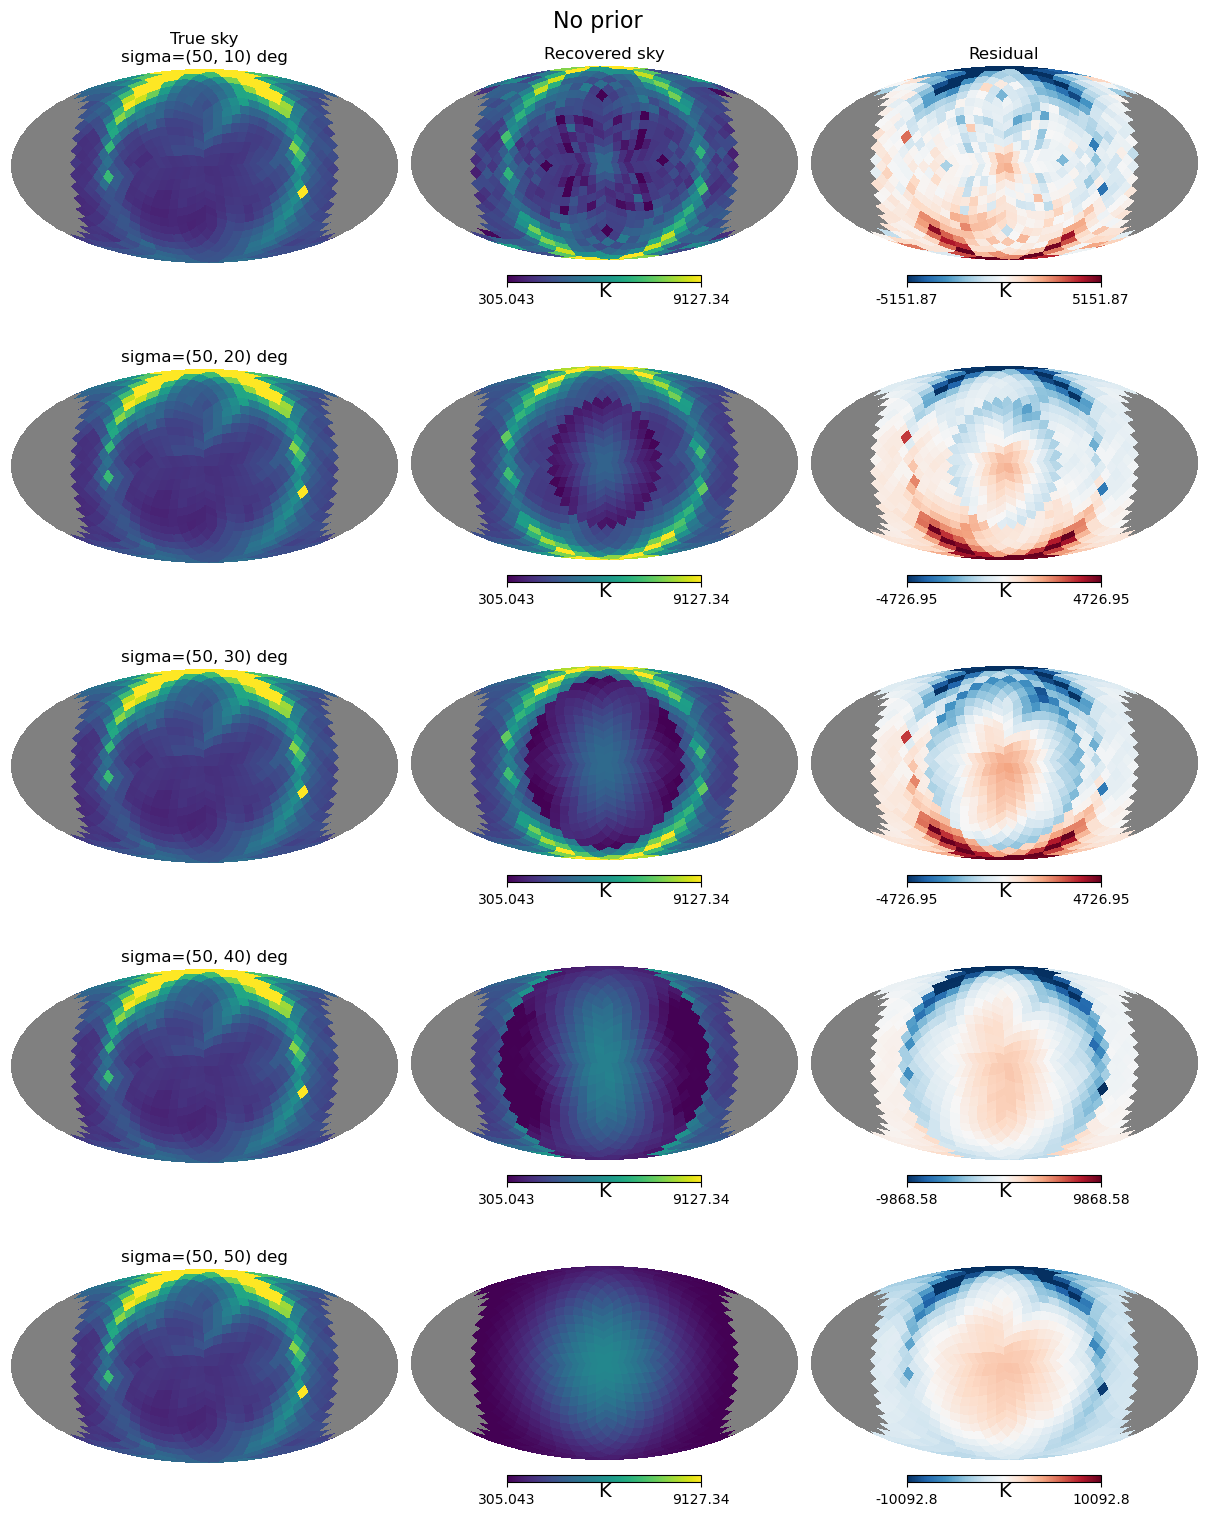

In [15]:
def plot_beam_comparison(results, figure_title):
    nrows, ncols = len(results), 3
    fig = plt.figure(figsize=(12, 3.0 * nrows))
    fig.suptitle(figure_title, fontsize=16, y=0.995)
    columns = ["True sky", "Recovered sky", "Residual"]

    sky_values = []
    for res in results:
        pix = res["pixel_indices"]
        sky_values.extend([res["sky_map"][pix], res["sky_est_patch"]])
    sky_vmin, sky_vmax = np.percentile(np.concatenate(sky_values), [2, 98])

    for row, res in enumerate(results):
        rot = rot_to_pixel_center(res["nside"], res["pixel_indices"])
        truth = res["sky_map"][res["pixel_indices"]]
        recovered = res["sky_est_patch"]
        residual = recovered - truth

        rmax = max(np.percentile(np.abs(residual), 98), 1e-12)
        maps = [res["truth_patch_map"], res["recovered_map"], res["residual_map"]]
        limits = [(sky_vmin, sky_vmax), (sky_vmin, sky_vmax), (-rmax, rmax)]
        cmaps = ["viridis", "viridis", "RdBu_r"]

        for col, (map_values, (lo, hi), cmap) in enumerate(zip(maps, limits, cmaps)):
            title = columns[col] if row == 0 else ""
            if col == 0:
                title = f"{title}\n{res['beam_label']}" if title else res["beam_label"]
            hp.mollview(
                map_values,
                fig=fig.number,
                sub=(nrows, ncols, row * ncols + col + 1),
                rot=rot,
                title=title,
                unit="K",
                min=lo,
                max=hi,
                cmap=cmap,
                cbar=(col != 0),
                notext=True,
            )

    plt.tight_layout(rect=[0, 0, 1, 0.975])
    plt.show()


plot_beam_comparison(no_prior_results, "No prior")



RUNNING NSIDE=8, beam sigma=(50, 10) deg, Mild prior
Using example asymmetric beam at 70.00 MHz: sigma=(50, 10) deg
Beam NSIDE: 8
Beam sum: 1.0
Beam max: 0.017861617623423188


100%|██████████| 480/480 [00:06<00:00, 71.91it/s]



Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 480/480 [00:06<00:00, 72.08it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 480
Number of selected pixels: 592


...

100%|██████████| 480/480 [00:06<00:00, 71.80it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 480
Number of selected pixels: 592


100%|██████████| 480/480 [00:06<00:00, 72.08it/s]


Using sky prior: sigma = 670 K, inv_var = 2.23e-06
Selected pixels: 592 / 768
Forward model relative error ||A sky - TOD|| / ||TOD||: 1.6820857820235317e-16
TOD fit relative error ||A recovered - TOD|| / ||TOD||: 2.246784095133675e-05
Operator rank: 11/592
Operator condition number: 5.317997377693895e+18


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_43793/3709752731.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.975])


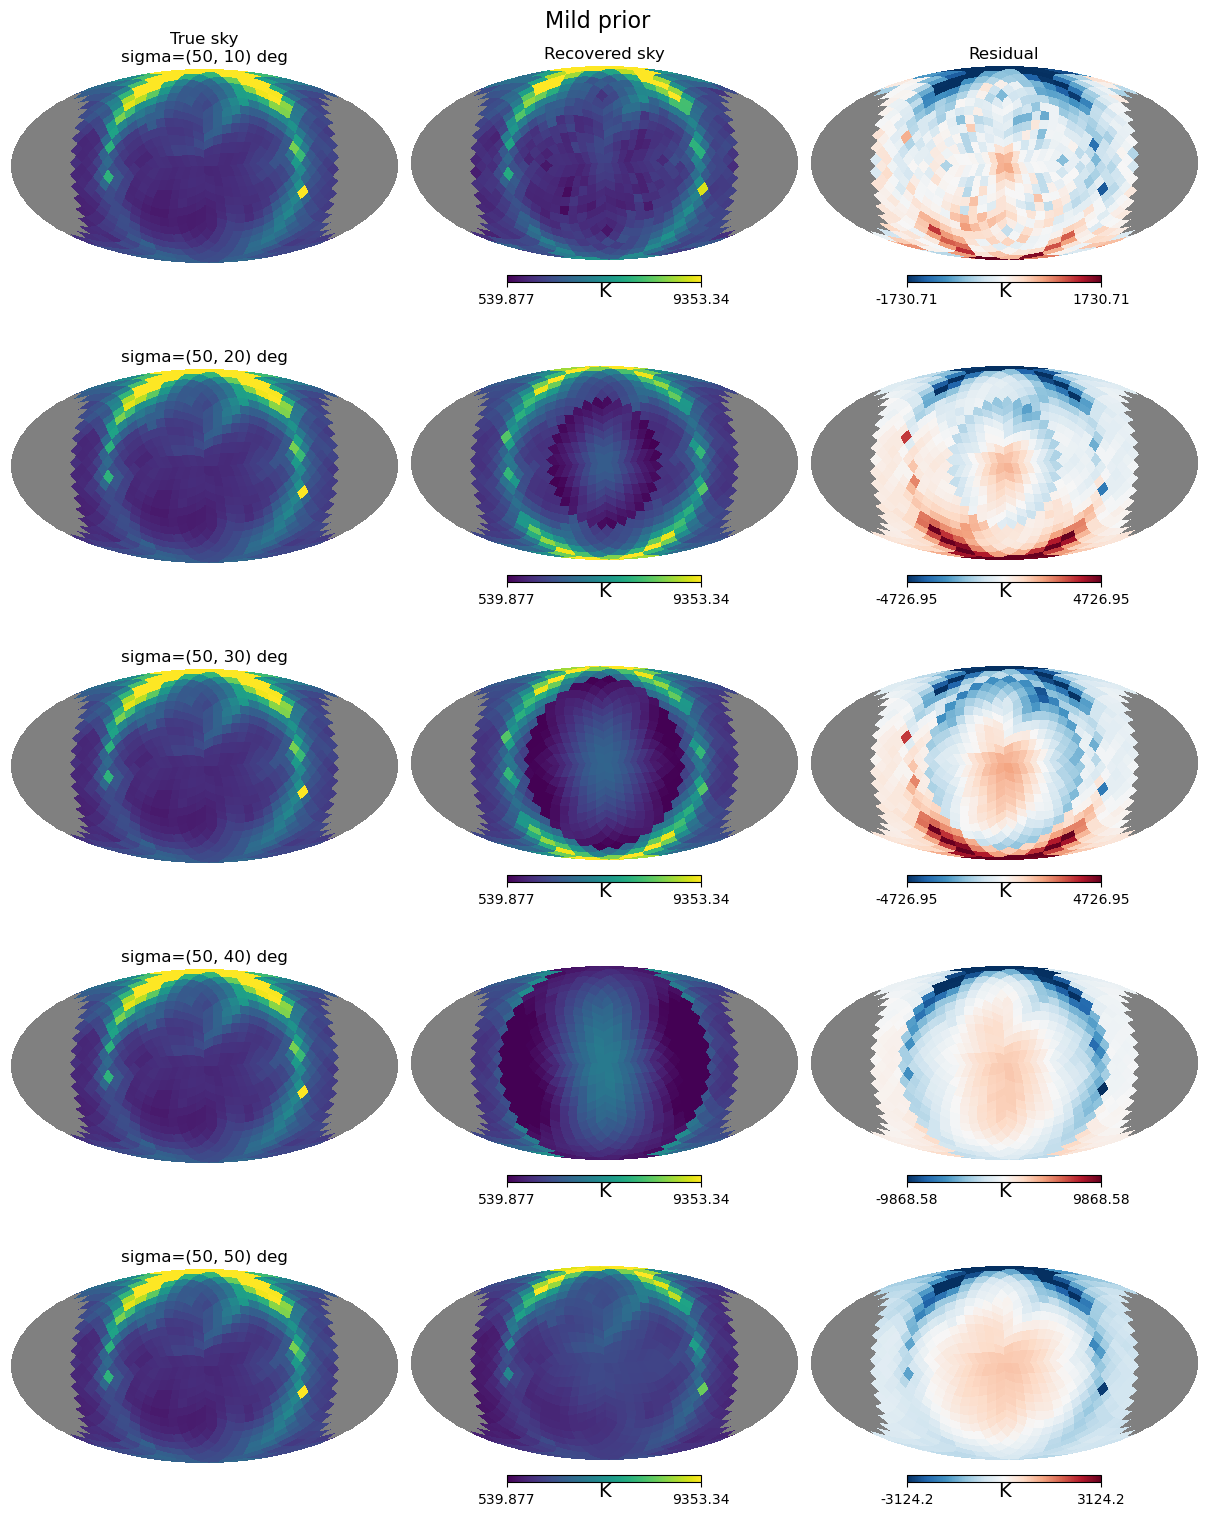

In [16]:
mild_prior_results = [
    run_beam_case(
        sigma_minor_deg,
        prior_label="Mild prior",
        prior_sigma_factor=MILD_PRIOR_SIGMA_FACTOR,
    )
    for sigma_minor_deg in BEAM_SIGMA_MINOR_DEG_LIST
]

plot_beam_comparison(mild_prior_results, "Mild prior")
